# **Tweet Sentiment Analysis with RNNs**

### **Assignment 4a - Natural Language Processing - MSc. Computer Science, AUE[2025-2026]**

> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

> Electra Papadopoulou, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> elec.papadopoulou@aueb.gr

> Leonidas Kontogiannis, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> leo.kontogiannis@aueb.gr

## **Text Classification with RNNs**

In [ ]:
%pip install matplotlib seaborn nltk scikit-learn gensim numpy torch --quiet

## **Imports**

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
os.environ["KAGGLE_USERNAME"] = "" #add your own username
os.environ["KAGGLE_KEY"] = "" # add your own key

In [ ]:
!pip install -q kaggle
DATA_DIR = "/content/data"
!mkdir -p $DATA_DIR

!kaggle competitions download -c twitter-sentiment-analysis2 -p $DATA_DIR --force
!unzip -qo "$DATA_DIR/twitter-sentiment-analysis2.zip" -d $DATA_DIR

!ls -lh $DATA_DIR


  0% 0.00/14.6M [00:00<?, ?B/s]
100% 14.6M/14.6M [00:00<00:00, 814MB/s]
total 48M
-rw-r--r-- 1 root root  25M Nov 28  2019 test.csv
-rw-r--r-- 1 root root 8.3M Nov 28  2019 train.csv
-rw-r--r-- 1 root root  15M Nov 28  2019 twitter-sentiment-analysis2.zip


In [ ]:
try:
    df = pd.read_csv("/content/data/train.csv")
except UnicodeDecodeError:
    df = pd.read_csv("/content/data/train.csv", encoding="ISO-8859-1")

print("Loaded CSV successfully.")
print(df.shape)
df.head()

Loaded CSV successfully.
(99989, 3)


,ItemID,Sentiment,SentimentText
0,1,0,is so sad for my APL frie...
1,2,0,I missed the New Moon trail...
2,3,1,omg its already 7:30 :O
3,4,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,i think mi bf is cheating on me!!! ...


In [ ]:
# Display basic info
print("Full dataset shape:", df.shape)
print(df['Sentiment'].value_counts())

Full dataset shape: (99989, 3)
Sentiment
1    56457
0    43532
Name: count, dtype: int64


### **Exploring the Dataset**

In [ ]:
x, y = df['SentimentText'], df['Sentiment']
print(len(x))
print(len(y))

99989
99989


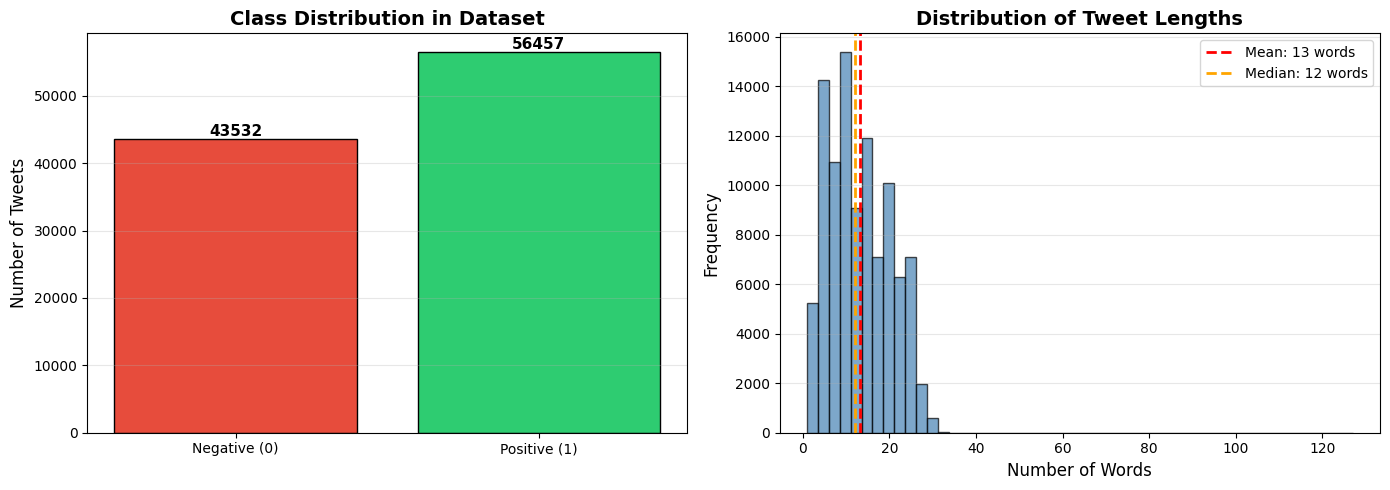

DATASET SUMMARY
Total tweets: 99989
Negative tweets: 43532 (43.5%)
Positive tweets: 56457 (56.5%)

Review Length Statistics:
  Min length: 1 words
  Max length: 127 words
  Mean length: 13.3 words
  Median length: 12.0 words
  Std deviation: 7.0 words


In [ ]:
import matplotlib.pyplot as plt

# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = np.bincount(y)
axes[0].bar(['Negative (0)', 'Positive (1)'], class_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
# Add count labels on bars
for i, count in enumerate(class_counts):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Tweet Length Distribution
tweet_lengths = [len(str(tweet).split()) for tweet in x]
axes[1].hist(tweet_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(tweet_lengths), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(tweet_lengths):.0f} words')
axes[1].axvline(np.median(tweet_lengths), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(tweet_lengths):.0f} words')
axes[1].set_xlabel('Number of Words', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Total tweets: {len(x)}")
print(f"Negative tweets: {class_counts[0]} ({class_counts[0]/len(x)*100:.1f}%)")
print(f"Positive tweets: {class_counts[1]} ({class_counts[1]/len(x)*100:.1f}%)")
print(f"\nReview Length Statistics:")
print(f"  Min length: {min(tweet_lengths)} words")
print(f"  Max length: {max(tweet_lengths)} words")
print(f"  Mean length: {np.mean(tweet_lengths):.1f} words")
print(f"  Median length: {np.median(tweet_lengths):.1f} words")
print(f"  Std deviation: {np.std(tweet_lengths):.1f} words")
print("="*60)

###  **Preprocess dataset**

In [ ]:
!python -m spacy download en_core_web_sm -q

In [ ]:
import spacy
import re
from tqdm import tqdm

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
# disabling parser and ner may speed up processing since you only need POS + lemma

docs = []
symbol_word_pattern = re.compile(r'\s*[\@\#\&][^\s]+')
html_entity_pattern = re.compile(r'&[a-z]+;')
url_pattern = re.compile(r'https?://\S+|www\.\S+')


for doc_text in tqdm(x):
    # Remove symbol prefix words
    doc_clean = symbol_word_pattern.sub(' ', doc_text)
    # Remove HTML entities
    doc_clean = html_entity_pattern.sub(' ', doc_clean)
    #Remove URLs
    doc_clean = url_pattern.sub(' ', doc_clean)
    # Remove non-word characters (punctuation etc)
    # doc_clean = re.sub(r'\W', ' ', str(doc_clean))
    # Remove single characters (optional)
    #doc_clean = re.sub(r'\s+[a-zA-Z]\s+', ' ', doc_clean)
    # Collapse multiple spaces
    doc_clean = re.sub(r'\s+', ' ', doc_clean, flags=re.I)
    # Lowercase
    doc_clean = doc_clean.lower().strip()

    # Process with spaCy
    doc = nlp(doc_clean)
    tokens = []
    for token in doc:
        tokens.append(token.lemma_)
    # Reconstruct document string
    docs.append(" ".join(tokens))

print("\nOriginal tweet text:\n{}".format(x[0]))
print("\nFiltered tweet text:\n{}".format(docs[0]))
print("\nLabel:\n", y[0])

100%|██████████| 99989/99989 [07:15<00:00, 229.66it/s]


Original tweet text:
                     is so sad for my APL friend.............

Filtered tweet text:
be so sad for my apl friend .............

Label:
 0


In [ ]:
import random

for i in range(10):
    idx = random.randint(0, len(x) - 1)
    print(f"\n===== Sample {i+1} (index {idx}) =====")
    print("\nOriginal tweet text:\n{}".format(x[idx]))
    print("\nFiltered tweet text:\n{}".format(docs[idx]))
    print("\nLabel:\n{}".format(y[idx]))



===== Sample 1 (index 11120) =====

Original tweet text:
#mygarage - new hashtag for the interesting rides that I sometimes find in my garage  http://twitpic.com/6qvkc

Filtered tweet text:
- new hashtag for the interesting ride that I sometimes find in my garage

Label:
1

===== Sample 2 (index 3492) =====

Original tweet text:
 Sometime in the night, I had to get up and drag my cat to bed because she was scratching at the door. Now my tummy's all scratched.

Filtered tweet text:
sometime in the night , I have to get up and drag my cat to bed because she be scratch at the door . now my tummy 's all scratch .

Label:
0

===== Sample 3 (index 23254) =====

Original tweet text:
@aaroncarter7 u never got back 2  me about the internship/Job thing  and you never said if u liked the banner i made  #AC 760 490 9435

Filtered tweet text:
u never get back 2 I about the internship / job thing and you never say if u like the banner I make 760 490 9435

Label:
0

===== Sample 4 (index 59393) ====

### **Split dataset into train (70%) , test (15%) and dev (15%)**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%) and temp (30%)
x_train, x_temp, y_train, y_temp = train_test_split(
    docs,
    y,
    test_size=0.30,
    stratify=y,          # preserve class proportions
    random_state=2025
)

# Split temp (30%) into dev (15%) and test (15%)
x_dev, x_test, y_dev, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,      # 50% of 30% = 15%
    stratify=y_temp,
    random_state=2025
)

# Confirm split sizes
print(f"Train: {len(x_train)}  Dev: {len(x_dev)}  Test: {len(x_test)}")

# Verify label balance
for name, labels in [("Train", y_train), ("Dev", y_dev), ("Test", y_test)]:
    print(f"\n{name} distribution:")
    print(pd.Series(labels).value_counts(normalize=True).round(3))


Train: 69992  Dev: 14998  Test: 14999

Train distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Dev distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64

Test distribution:
Sentiment
1    0.565
0    0.435
Name: proportion, dtype: float64


## **Feature extraction (TF-IDF n-gram features)**

In this step, we convert the preprocessed text data into numerical feature vectors using the **TF-IDF (Term Frequency–Inverse Document Frequency)** representation. TF-IDF measures how important a word is in a document relative to the entire dataset, allowing the model to emphasize informative tokens while discounting common and less meaningful ones.

We apply the `TfidfVectorizer` with the following configuration parameters:

- **n-gram range = (1, 3):** Extracts unigrams, bigrams, and trigrams. This allows the model to capture individual words as well as short phrases that may express sentiment (e.g., *"not good"*, *"very happy"*, *"love this"*).
- **max_features = 30,000:** Limits the vocabulary to the most informative 30,000 terms for computational efficiency.
- **stop_words = 'english':** Removes common non-informative English words (e.g., "the", "and", "is").
- **sublinear_tf = True:** Applies logarithmic scaling to term frequencies, reducing the influence of repeated words.

The resulting TF-IDF vectors are represented as **sparse matrices**, where only non-zero weights are stored to minimize memory usage. After transformation, we inspect:
1. The vocabulary learned by the vectorizer.
2. The dimensionality of the training and test feature matrices.
3. The most influential (highest-weighted) tokens in a sample tweet, which provides interpretability regarding how the model represents text input.

In [ ]:
#Feature extraction (TF-IDF n-gram features)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Use unigram & bi-gram tf*idf features
#vectorizer = TfidfVectorizer(ngram_range = (1, 2),max_features = 5000, sublinear_tf = True)

# Use unigram & bi-gram & tri-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, sublinear_tf = True, stop_words='english')

# Reuse the same TF-IDF vectorizer for all splits
x_train_tfidf = vectorizer.fit_transform(x_train)
x_dev_tfidf   = vectorizer.transform(x_dev)
x_test_tfidf  = vectorizer.transform(x_test)

print([vectorizer.get_feature_names_out()[i] for i in range(1, 50, 5)]) # Shows the learned vocabulary
print(len(vectorizer.get_feature_names_out())) # Number of features == 30000


# Low-dimensional dense representations for MLP
svd_mlp = TruncatedSVD(n_components=500, random_state=2025)
X_train_svd = svd_mlp.fit_transform(x_train_tfidf)
X_dev_svd   = svd_mlp.transform(x_dev_tfidf)
X_test_svd  = svd_mlp.transform(x_test_tfidf)

print("Done Creating SVD")

['aaa', 'aaah', 'aahhh', 'aawww', 'abby', 'ability', 'able come', 'able make', 'able tell', 'absence']
30000
Done Creating SVD


In [ ]:
print(vectorizer.get_feature_names_out()[:50])  # show up to 50 features

['aa' 'aaa' 'aaaa' 'aaaaaah' 'aaaand' 'aaaaw' 'aaah' 'aaahh' 'aaaw' 'aah'
 'aahh' 'aahhh' 'aar' 'aaron' 'aaw' 'aaww' 'aawww' 'ab' 'abandon' 'abba'
 'abbey' 'abby' 'abc' 'aber' 'aberdeen' 'abi' 'ability' 'abis' 'abit'
 'able' 'able afford' 'able come' 'able early' 'able eat' 'able hang'
 'able help' 'able make' 'able meet' 'able sleep' 'able stay' 'able talk'
 'able tell' 'able watch' 'aboard' 'abraham' 'abroad' 'absence' 'absent'
 'absinthe' 'absolute']


In [ ]:
print(f'Shape of training data: {x_train_tfidf.shape}')
print(f'Shape of test data: {x_test_tfidf.shape}')

# TFIDF Vectorizer returns Sparse matrix structures --> Saves only the cells which are not zero (be memory efficient), so it can not be printed directly
print(x_test_tfidf.todense()[0, :5000])

Shape of training data: (69992, 30000)
Shape of test data: (14999, 30000)
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
doc_index = 0
doc_vector = x_test_tfidf[doc_index].todense()
features = vectorizer.get_feature_names_out()

# Build a DataFrame: each word → its TF-IDF weight in this document
df_doc = pd.DataFrame({
    'Feature': features,
    'TFIDF': doc_vector.tolist()[0]  # convert to 1D list
})

# Show only non-zero entries (words that actually appear in the tweet)
df_nonzero = df_doc[df_doc['TFIDF'] > 0].sort_values(by='TFIDF', ascending=False)

print(f"Number of non-zero features in this document: {len(df_nonzero)}")
print(df_nonzero.head())  # top weighted words


Number of non-zero features in this document: 4
      Feature     TFIDF
24658   spill  0.582214
8918    homie  0.561572
4846       dm  0.433804
26960    true  0.396834


### **Model Training: Baseline and Logistic Regression Classifiers**

In this section, we compare three different classification approaches for tweet sentiment prediction. The aim is to evaluate how different feature representations (TF-IDF vs. Boolean presence) and model assumptions impact classification performance.

#### 1. **Majority Baseline Classifier**
The baseline model predicts the sentiment class that appears most frequently in the training set.  
This provides a **lower-bound performance benchmark**. A good classifier should significantly outperform this baseline.

#### 2. **Logistic Regression with TF-IDF and Character-Level Features**
This model uses a **hybrid feature representation**:
- **Word-level TF-IDF** features (unigrams, bigrams, trigrams)
- **Character-level n-grams** to capture stylistic cues, misspellings, slang, and emojis often found in tweets.

Additionally, we apply:
- **Feature selection using Mutual Information (`SelectKBest`)** to keep the most informative 30,000 features.
- **Class-balanced Logistic Regression** to counteract class imbalance.

This model is expected to capture both semantic and stylistic sentiment signals.

#### 3. **Logistic Regression with Boolean Bag-of-Words Features**
This model uses a **binary CountVectorizer** that records only the *presence or absence* of terms.  
This representation is simpler and may reduce noise, but it ignores term frequency and relative importance of words.

In [ ]:
# === Two Pipelines: Baseline, Logistic Regression (TF-IDF) ===
import time
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Majority Baseline (most_frequent)
baseline = Pipeline([
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=2025)),
])

# 2) Logistic Regression (TF-IDF)
vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(ngram_range = (1, 3),max_features = 30000, stop_words='english', sublinear_tf = True)),
    # Character features help with misspellings, slang, and emojis.
    ('char', TfidfVectorizer(analyzer='char', ngram_range=(3,5), max_features=20000))
])

lr_tfidf = Pipeline([
    ('vectorizer', vectorizer),
    ('selector', SelectKBest(mutual_info_classif, k=30000)),
    ('classifier', LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1))
])

# Quick sanity fits + metrics
def quick_report(name, pipe, x_train, y_train, x_test, y_test):
    t0 = time.time()
    pipe.fit(x_train, y_train)
    dt = time.time() - t0
    ytr = pipe.predict(x_train)
    yte = pipe.predict(x_test)
    print(f"✓ {name} trained in {dt:.3f}s")
    print(f"  Train  Acc: {accuracy_score(y_train, ytr):.4f} | F1: {f1_score(y_train, ytr):.4f}")
    print(f"  Test   Acc: {accuracy_score(y_test, yte): .4f} | F1: {f1_score(y_test, yte): .4f}\n")
    return pipe

print("=== Evaluation ===")
baseline        = quick_report("Baseline",          baseline, x_train, y_train, x_test, y_test)
lr_tfidf        = quick_report("LR (TF-IDF)",       lr_tfidf, x_train, y_train, x_test, y_test)

trained_models = [
    ("Majority Baseline", baseline),
    ("TF-IDF+LR", lr_tfidf)
]


=== Evaluation ===
✓ Baseline trained in 0.009s
  Train  Acc: 0.5646 | F1: 0.7217
  Test   Acc:  0.5646 | F1:  0.7217

✓ LR (TF-IDF) trained in 613.536s
  Train  Acc: 0.8310 | F1: 0.8478
  Test   Acc:  0.7685 | F1:  0.7924



##  **Creating TF-IDF MLP**

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
class MLP_tf_idf(nn.Module):
    def __init__(self, input_dim=500, hidden_sizes=[256], dropout_prob=0.7):
        super().__init__()

        layers = []
        dim = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            dim = h

        # Final layer: 2 classes (negative/positive)
        layers.append(nn.Linear(dim, 2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

mlp_classifier = MLP_tf_idf()
print(mlp_classifier)

# Count the total number of parameters
total_params = sum(p.numel() for p in mlp_classifier.parameters())
print(f"Total number of parameters: {total_params}")

# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")

MLP_tf_idf(
  (model): Sequential(
    (0): Linear(in_features=500, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.7, inplace=False)
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total number of parameters: 128770
Number of trainable parameters: 128770


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_svd, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_dev_tensor = torch.tensor(X_dev_svd, dtype=torch.float32)
y_dev_tensor = torch.tensor(y_dev.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_svd, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [ ]:
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # pairs each input vector with its label
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # divides it into mini-batches of 256 and reshuffles data every epoch (shuffle=True)

dev_dataset = TensorDataset(X_dev_tensor, y_dev_tensor)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) #see whats best, shuffle=True or False

## **Creating the final MLP model**

In [ ]:
from sklearn.metrics import f1_score

def train_final_model(hidden_sizes, dropout_prob, epochs, lr=0.001):
    model = MLP_tf_idf(hidden_sizes=hidden_sizes, dropout_prob=0.7).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1_score": [],
        "val_f1_score": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        all_train_preds = []
        all_train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds_train = torch.argmax(logits, dim=1)
            all_train_preds.append(preds_train.cpu())
            all_train_labels.append(y_batch.cpu())

        # --- Training metrics ---
        train_preds_tensor = torch.cat(all_train_preds)
        train_labels_tensor = torch.cat(all_train_labels)
        train_acc = (train_preds_tensor == train_labels_tensor).float().mean().item()
        train_f1 = f1_score(train_labels_tensor, train_preds_tensor, average='macro')

        avg_train_loss = running_loss / len(train_loader)

        # --- Validation metrics ---
        model.eval()
        with torch.no_grad():
            dev_logits = model(X_dev_tensor.to(device))
            dev_loss = criterion(dev_logits, y_dev_tensor.to(device)).item()
            dev_preds = torch.argmax(dev_logits, dim=1).cpu()
            val_acc = (dev_preds == y_dev_tensor).float().mean().item()
            val_f1 = f1_score(y_dev, dev_preds, average='macro')

        # --- Append to history ---
        history["train_loss"].append(avg_train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)
        history["train_f1_score"].append(train_f1)
        history["val_f1_score"].append(val_f1)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss={avg_train_loss:.4f} | Dev Loss={dev_loss:.4f} | "
              f"Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | "
              f"Train F1={train_f1:.4f} | Val F1={val_f1:.4f}")

    return model, history



In [ ]:
best_model_mlp, history_mlp = train_final_model(
    hidden_sizes=[512],
    dropout_prob=0.7,
    epochs=26,
    lr=0.001
)

Epoch 1/26 | Train Loss=0.5853 | Dev Loss=0.5478 | Train Acc=0.6774 | Val Acc=0.7138 | Train F1=0.6451 | Val F1=0.7021
Epoch 2/26 | Train Loss=0.5390 | Dev Loss=0.5460 | Train Acc=0.7205 | Val Acc=0.7169 | Train F1=0.7091 | Val F1=0.7022
Epoch 3/26 | Train Loss=0.5343 | Dev Loss=0.5453 | Train Acc=0.7246 | Val Acc=0.7180 | Train F1=0.7134 | Val F1=0.7092
Epoch 4/26 | Train Loss=0.5317 | Dev Loss=0.5454 | Train Acc=0.7272 | Val Acc=0.7176 | Train F1=0.7163 | Val F1=0.7078
Epoch 5/26 | Train Loss=0.5284 | Dev Loss=0.5443 | Train Acc=0.7287 | Val Acc=0.7177 | Train F1=0.7178 | Val F1=0.7082
Epoch 6/26 | Train Loss=0.5254 | Dev Loss=0.5443 | Train Acc=0.7315 | Val Acc=0.7172 | Train F1=0.7210 | Val F1=0.7037
Epoch 7/26 | Train Loss=0.5226 | Dev Loss=0.5444 | Train Acc=0.7349 | Val Acc=0.7206 | Train F1=0.7247 | Val F1=0.7113
Epoch 8/26 | Train Loss=0.5196 | Dev Loss=0.5444 | Train Acc=0.7354 | Val Acc=0.7186 | Train F1=0.7250 | Val F1=0.7062
Epoch 9/26 | Train Loss=0.5166 | Dev Loss=0.5446

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

best_model_mlp.eval()
best_model_mlp.to("cpu")  # move to CPU for sklearn

# Dev predictions
with torch.no_grad():
    dev_logits = best_model_mlp(X_dev_tensor)
    dev_preds = torch.argmax(dev_logits, dim=1)

# Test predictions
with torch.no_grad():
    test_logits = best_model_mlp(X_test_tensor)
    test_preds = torch.argmax(test_logits, dim=1)

print(f"Dev Accuracy:  {accuracy_score(y_dev, dev_preds)*100:.2f}%")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")

print("\nDev performance:")
print(classification_report(y_dev, dev_preds, target_names=['Negative', 'Positive'], digits=4))

print("\nTest performance:")
print(classification_report(y_test, test_preds, target_names=['Negative', 'Positive'], digits=4))


Dev Accuracy:  72.12%
Test Accuracy: 72.23%

Dev performance:
              precision    recall  f1-score   support

    Negative     0.7096    0.6087    0.6553      6530
    Positive     0.7281    0.8079    0.7659      8468

    accuracy                         0.7212     14998
   macro avg     0.7188    0.7083    0.7106     14998
weighted avg     0.7200    0.7212    0.7177     14998


Test performance:
              precision    recall  f1-score   support

    Negative     0.7134    0.6054    0.6550      6530
    Positive     0.7275    0.8125    0.7677      8469

    accuracy                         0.7223     14999
   macro avg     0.7205    0.7089    0.7113     14999
weighted avg     0.7214    0.7223    0.7186     14999



In [ ]:
best_model_mlp.eval()
best_model_mlp.to("cpu")

# --- Validation accuracy ---
y_pred_val = torch.argmax(best_model_mlp(X_dev_tensor), dim=1)
val_acc = accuracy_score(y_dev, y_pred_val)
print(f'Validation Accuracy: {val_acc*100:.2f}%')

# --- Test accuracy ---
y_pred_test = torch.argmax(best_model_mlp(X_test_tensor), dim=1)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'Test Accuracy: {test_acc*100:.2f}%')


Validation Accuracy: 72.12%
Test Accuracy: 72.23%


## **Data Preprocessing for the RNN**

### vocabulary building

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq, max_vocab_size=None):
    # counte every word
    cnt = Counter()
    for doc in texts:
        for tok in doc.split():
            cnt[tok] += 1

    # special tokens
    specials = ["<pad>", "<unk>"]

    # remove infrequent words
    items = [w for w,f in cnt.most_common() if f >= min_freq]

    if max_vocab_size:
        items = items[:max_vocab_size - len(specials)]

    idx2str = specials + items
    str2idx = {w:i for i,w in enumerate(idx2str)}
    return str2idx, idx2str, cnt

# Build on train only
str2idx, idx2str, counter = build_vocab(x_train, min_freq=1, max_vocab_size=50000)
vocab_size = len(idx2str)
print("Vocab size:", vocab_size)
print("Top 20 tokens:", idx2str[2:22])

Vocab size: 34199
Top 20 tokens: ['be', 'to', 'you', 'the', 'it', 'and', 'have', 'I', 'that', 'my', 'for', 'in', 'm', 'not', 'do', 'of', 'get', 'on', 'so', 'but']


In [ ]:
train_clean_x = []
train_clean_y = []

for text, label in zip(x_train, y_train):
    if text.strip() != "":
        train_clean_x.append(text)
        train_clean_y.append(label)

dev_clean_x = []
dev_clean_y = []

for text, label in zip(x_dev, y_dev):
    if text.strip() != "":
        dev_clean_x.append(text)
        dev_clean_y.append(label)

test_clean_x = []
test_clean_y = []

for text, label in zip(x_test, y_test):
    if text.strip() != "":
        test_clean_x.append(text)
        test_clean_y.append(label)

tokenized_train = [tweet.split() for tweet in train_clean_x]
#tokenized_dev = [tweet.split() for tweet in x_dev]
#tokenized_text = [tweet.split() for tweet in x_test]

print(tokenized_train[:3])

print("Length:", len(tokenized_train))
print("Empty docs:", sum(1 for d in tokenized_train if len(d) == 0))

[['my', 'bag', 'steal', 'from', 'beneath', 'table', 'pub', 'tonight', 'it', 'have', 'all', 'my', 'stuff', 'in', 'it', 'lot', 'of', 'bit', 'kinda', 'know', 'how', 'feel', 'bout', 'diary'], ['aww', 'm', 'glad', 'that', 'he', 'give', 'her', 'shoutout', 'she', 'go', 'to', 'bed', 'like', 'minute', 'too', 'early'], ['and', 'of', 'course', 'have', 'access', 'to', 'my', 'halo', 'mythic', 'map', 'pack', 're', 'download', 'but', 'bad', 'news', 'not', 'the', 'legendary', 'map', 'pack', 'ugh']]
Length: 69654
Empty docs: 0


### Create the word Embending using the train dataset

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.5 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

EMB_DIM = 100

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=EMB_DIM,
    window=5,
    min_count=1,
    workers=-1,
    sg=1,          # 1 = skip-gram (better for rare/informal words), 0 = CBOW
    epochs=10
)

print("Word2Vec vocab size:", len(w2v_model.wv)) # # number of tokens in vocabulary
print(w2v_model.wv['happy'])     # try an example lookup

Word2Vec vocab size: 34197
[-0.00913394 -0.0081252  -0.00935055  0.00185385  0.00206219  0.00621015
  0.00395165  0.00613848  0.0018229  -0.00218558 -0.00207128 -0.00094988
 -0.00405622  0.00665863 -0.00742867  0.00149706  0.00411903 -0.00405714
 -0.0094529   0.00720567 -0.00719067  0.00944345  0.00900583  0.00625733
  0.00981809  0.00289842 -0.00659959  0.00817862  0.00577767  0.00784847
  0.00122139 -0.00198215  0.00997012  0.0078302  -0.00151193  0.00393101
  0.00903581 -0.00366737 -0.00616007  0.00572613 -0.00578633 -0.0044496
  0.00802283 -0.00867459 -0.00849164 -0.00707839 -0.00094325 -0.00904254
 -0.0034793  -0.00866879  0.00381881 -0.00620975 -0.001587   -0.00770908
 -0.00169522 -0.00091709  0.00633255 -0.00695397  0.00292575  0.00532711
  0.00903627  0.00285376 -0.0040861  -0.00486669 -0.00586249  0.0086173
  0.0080101  -0.00814895  0.00340366 -0.00510704  0.00815493 -0.00262431
  0.00339343  0.00796371 -0.00754524  0.00120827 -0.00027068  0.00379344
 -0.0095896   0.00332912 -

In [ ]:
import numpy as np

embedding_matrix = np.zeros((vocab_size, EMB_DIM), dtype=np.float32)

for idx, word in enumerate(idx2str):
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(EMB_DIM,))

embedding_layer = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=EMB_DIM,
    padding_idx=str2idx["<pad>"]
)

# load our custom matrix
embedding_layer.weight.data.copy_(torch.from_numpy(embedding_matrix))

embedding_layer.weight.requires_grad = True   # fine-tune

def tweet_to_vec(tokens, w2v_model, embedding_dim=EMB_DIM):
    vectors = []
    for token in tokens:
        if token in w2v_model.wv:
            vectors.append(w2v_model.wv[token])
    if len(vectors) == 0:
        # return zero vector if no tokens matched
        return np.zeros(embedding_dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

### PyTorch Dataset + DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

#y_train = np.array(y_train)
#y_dev   = np.array(y_dev)
#y_test  = np.array(y_test)

class TweetsSeqDataset(Dataset):
    def __init__(self, texts, labels, str2idx):
        """
        texts: list of cleaned strings (space-separated tokens)
        labels: list/array of ints (0..C-1)
        str2idx: dict token->index, with "<pad>" and "<unk>"
        """
        self.texts = texts
        self.labels = np.array(labels)
        self.str2idx = str2idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.texts[idx].split()
        indices = [self.str2idx.get(t, self.str2idx["<unk>"]) for t in tokens]
        if len(indices) == 0:
            # avoid zero-length sequences (replace with pad token index so collate handles it)
            indices = [self.str2idx["<pad>"]]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def collate_batch_pad(batch):
    """
    batch: list of (indices_tensor, label_tensor)
    returns:
      tokens_padded: (B, T) LongTensor
      lengths: (B,) LongTensor
      labels: (B,) LongTensor
    """
    tokens = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])
    lengths = torch.tensor([t.shape[0] for t in tokens], dtype=torch.long)
    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=str2idx["<pad>"])
    return tokens_padded, lengths, labels

In [ ]:
BATCH_SIZE = 256

train_ds = TweetsSeqDataset(train_clean_x, train_clean_y, str2idx)
dev_ds   = TweetsSeqDataset(dev_clean_x,   dev_clean_y,   str2idx)
test_ds  = TweetsSeqDataset(test_clean_x,  test_clean_y,  str2idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_pad)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch_pad)

print("Samples:", len(train_ds), len(dev_ds), len(test_ds))

Samples: 69654 14917 14921


## **Creating the RNN Model**

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim, attn_hidden_dim=None):
        """
        hidden_dim: dimension of BiRNN hidden states (per direction concatenated -> 2*hid)
        attn_hidden_dim: if provided, use a single hidden layer MLP for attention scores
        """
        super().__init__()
        if attn_hidden_dim is None:
            # single linear score: score = v^T tanh(W h + b)
            self.w = nn.Linear(hidden_dim, hidden_dim, bias=True)
            self.v = nn.Linear(hidden_dim, 1, bias=False)
            self.use_mlp = False
        else:
            # small MLP: h -> ReLU -> score
            self.mlp = nn.Sequential(
                nn.Linear(hidden_dim, attn_hidden_dim),
                nn.ReLU(),
                nn.Linear(attn_hidden_dim, 1)
            )
            self.use_mlp = True

    def forward(self, H, mask=None):
        """
        H: (B, T, hidden_dim)
        mask: (B, T) with 1 for token, 0 for pad (optional)
        Returns: context (B, hidden_dim) and attn_weights (B, T)
        """
        if self.use_mlp:
            scores = self.mlp(H).squeeze(-1)  # (B, T)
        else:
            x = torch.tanh(self.w(H))         # (B, T, hidden_dim)
            scores = self.v(x).squeeze(-1)    # (B, T)
        if mask is not None:
            # mask: 1 for valid, 0 for pad -> set pad scores to very negative
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(scores, dim=-1)  # (B, T)
        # compute weighted sum
        attn_weights_unsq = attn_weights.unsqueeze(-1)  # (B, T, 1)
        context = torch.sum(H * attn_weights_unsq, dim=1)  # (B, hidden_dim)
        return context, attn_weights

In [ ]:
class BiLSTMWithAttention(nn.Module):
    def __init__(self, embedding_matrix, pad_idx, hidden_size=256, num_layers=2,
                 dropout=0.3, bidirectional=True, rnn_type='lstm', attn_hidden_dim=None,
                 fine_tune_embeddings=True, num_classes=2, emb_dropout=0.2):
        """
        embedding_matrix: numpy array [vocab_size, emb_dim]
        pad_idx: index used for padding (so embedding_layer padding_idx)
        hidden_size: LSTM hidden size per direction
        num_layers: stacked RNN layers
        bidirectional: True
        rnn_type: 'lstm' or 'gru'  (you requested LSTM)
        attn_hidden_dim: if None -> single dense attention as in slides; else small MLP with this hidden dim
        fine_tune_embeddings: whether to allow embedding updates
        num_classes: number of output classes
        """
        super().__init__()
        emb_weights = torch.tensor(embedding_matrix, dtype=torch.float)
        vocab_size, emb_dim = emb_weights.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(emb_weights)
        self.embedding.weight.requires_grad = fine_tune_embeddings

        self.emb_dropout = nn.Dropout(emb_dropout) if emb_dropout and emb_dropout>0 else nn.Identity()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        num_directions = 2 if bidirectional else 1

        if rnn_type.lower() == 'lstm':
            self.rnn = nn.LSTM(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )
        else:
            self.rnn = nn.GRU(
                input_size=emb_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers>1 else 0.0,
                bidirectional=bidirectional
            )

        # attention sees concatenated hidden states size = hidden_size * num_directions
        attn_in_dim = hidden_size * num_directions
        self.attention = SelfAttention(attn_in_dim, attn_hidden_dim)

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(attn_in_dim, attn_in_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_in_dim//2, num_classes)
        )

    def forward(self, tokens, lengths):
        """
        tokens: (B, T) LongTensor
        lengths: (B,) LongTensor
        returns logits (B, num_classes), attn_weights (B, T)
        """
        mask = (tokens != self.embedding.padding_idx).long().to(tokens.device)  # (B, T)
        emb = self.embedding(tokens)  # (B, T, E)
        emb = self.emb_dropout(emb)

        # pack
        lengths_cpu = lengths.cpu()
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.rnn(packed)  # packed output
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # (B, T, num_directions*hidden)

        # out may be shorter in T than tokens due to pack/pad; ensure mask shape matches out.shape[1]
        if out.shape[1] != mask.shape[1]:
            # crop or pad mask appropriately
            if out.shape[1] < mask.shape[1]:
                mask = mask[:, :out.shape[1]]
            else:
                pad_extra = out.shape[1] - mask.shape[1]
                mask = torch.cat([mask, torch.zeros(mask.size(0), pad_extra, device=mask.device, dtype=mask.dtype)], dim=1)

        context, attn_weights = self.attention(out, mask=mask)  # context: (B, attn_in_dim)
        logits = self.classifier(context)  # (B, num_classes)
        return logits, attn_weights

### Utilities

In [ ]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    average_precision_score
)
import numpy as np
import torch

def compute_metrics_all(y_true, y_pred, y_prob, labels_list):
    """
    Computes:
    - per-class precision, recall, F1, AUC-PR
    - macro averages
    - overall accuracy
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ---------- overall accuracy ----------
    overall_acc = accuracy_score(y_true, y_pred)

    # ---------- per-class precision, recall, f1 ----------
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels_list, zero_division=0
    )

    # ---------- per-class AUC-PR ----------
    auc_pr = []
    for cls in labels_list:
        # binarize true labels
        y_true_bin = (y_true == cls).astype(int)
        y_prob_cls = y_prob[:, cls]

        try:
            auc = average_precision_score(y_true_bin, y_prob_cls)
        except ValueError:
            auc = 0.0

        auc_pr.append(auc)

    # ---------- macro metrics ----------
    macro_prec = np.mean(prec)
    macro_rec  = np.mean(rec)
    macro_f1   = np.mean(f1)
    macro_auc  = np.mean(auc_pr)

    # ---------- build dictionary ----------
    results = {
        "overall": {
            "accuracy": overall_acc
        },
        "per_class": {
            "precision": prec.tolist(),
            "recall": rec.tolist(),
            "f1": f1.tolist(),
            "auc_pr": auc_pr,
            "support": support.tolist()
        },
        "macro": {
            "precision": macro_prec,
            "recall": macro_rec,
            "f1": macro_f1,
            "auc_pr": macro_auc
        }
    }

    return results


In [ ]:
def evaluate_model(model, loader, labels_list):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for tokens, lengths, labels in loader:
            tokens  = tokens.to(device)
            lengths = lengths.to(device)
            labels  = labels.to(device)

            logits, _ = model(tokens, lengths)
            probs = torch.softmax(logits, dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_prob = np.array(all_prob)

    return compute_metrics_all(
        y_true=all_true,
        y_pred=all_pred,
        y_prob=all_prob,
        labels_list=labels_list
    )


### Training of the RNN

In [ ]:
import copy
import time

def train_one_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0.0
    n = 0
    for tokens, lengths, labels in tqdm(loader, desc="Train batches", leave=False):
        tokens = tokens.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(tokens, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        # gradient clipping
        if clip:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
    return total_loss / n

def run_training(
    model,
    train_loader,
    dev_loader,
    labels_list,
    lr=1e-3,
    epochs=20,
    patience=5,
    weight_decay=1e-5,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )

    # store best model parameters in memory
    best_model_state = None
    best_dev_f1 = -1.0

    best_epoch = -1

    history = {
        "train_loss": [],
        "dev_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_f1": [],
        "val_f1": []
    }

    no_improve = 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # -------------------------
        # TRAIN ONE EPOCH
        # -------------------------
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        # -------------------------
        # DEV LOSS
        # -------------------------
        model.eval()
        total_dev_loss = 0
        n_dev = 0
        with torch.no_grad():
            for tokens, lengths, labels in dev_loader:
                tokens = tokens.to(device)
                lengths = lengths.to(device)
                labels = labels.to(device)

                logits, _ = model(tokens, lengths)
                loss = criterion(logits, labels)

                total_dev_loss += loss.item() * labels.size(0)
                n_dev += labels.size(0)

        dev_loss = total_dev_loss / n_dev

        # -------------------------
        # METRICS (train + dev)
        # -------------------------
        train_metrics = evaluate_model(model, train_loader, labels_list)
        dev_metrics = evaluate_model(model, dev_loader, labels_list)

        train_acc = train_metrics["overall"]["accuracy"]
        dev_acc   = dev_metrics["overall"]["accuracy"]

        train_f1 = train_metrics["macro"]["f1"]
        dev_f1   = dev_metrics["macro"]["f1"]

        # -------------------------
        # STORE HISTORY
        # -------------------------
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(dev_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(dev_f1)

        took = time.time() - t0
        print(
            f"Epoch {epoch:02d} | "
            f"TrainLoss={train_loss:.4f} DevLoss={dev_loss:.4f} | "
            f"TrainF1={train_f1:.4f} DevF1={dev_f1:.4f} | "
            f"Time={took:.1f}s"
        )

        # -------------------------
        # EARLY STOPPING BASED ON DEV F1
        # -------------------------
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            print("  -> New best model found!")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping after {patience} epochs without improvement.")
                break

    # -------------------------
    # LOAD BEST MODEL (in-memory)
    # -------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history, best_dev_f1, best_epoch


## **Hyperparameter Tuning RNN model**

In [ ]:
import random
import itertools
import pprint
import json

random.seed(2025)

search_space = {
    "hidden_size": [64, 128],
    "num_layers": [2, 3, 4],
    "dropout": [0.2, 0.4, 0.6],
    "attn_hidden": [None, 64],   # None => single dense attention; 64 => small MLP
    "lr": [0.01, 0.001, 0.0001],
    "fine_tune_embeddings": [True]
}

keys, values = zip(*search_space.items())
grid_list = [dict(zip(keys, v)) for v in itertools.product(*values)]
print("Total trials:", len(grid_list))

seen_configs = set()

def sample_config():
    while True:
        config = {
            "hidden_size": random.choice(search_space["hidden_size"]),
            "num_layers": random.choice(search_space["num_layers"]),
            "dropout": random.choice(search_space["dropout"]),
            "attn_hidden": random.choice(search_space["attn_hidden"]),
            "lr": random.choice(search_space["lr"]),
            "fine_tune_embeddings": random.choice(search_space["fine_tune_embeddings"])
        }

        # Convert config to an immutable representation
        key = json.dumps(config, sort_keys=True)

        if key not in seen_configs:
            seen_configs.add(key)
            return config

Total trials: 108


In [ ]:
import random
import copy

random.seed(SEED)

MAX_EPOCHS = 10
PATIENCE = 5

def random_search(
    train_loader,
    dev_loader,
    labels_list,
    num_samples=10
):

    best_model_overall = None
    best_hparams = None
    best_score = -1
    best_history = None

    for i in range(num_samples):
        print(f"\n===== Random Search Trial {i+1}/{num_samples} =====")

        # Sample hyperparameters
        hparams = sample_config()
        print("Hyperparameters:", hparams)

        # Create model with sampled hyperparameters
        model = BiLSTMWithAttention(
            embedding_matrix=embedding_matrix,
            pad_idx=str2idx["<pad>"],
            hidden_size=hparams["hidden_size"],
            num_layers=hparams["num_layers"],
            dropout=hparams["dropout"],
            attn_hidden_dim=hparams["attn_hidden"],
            fine_tune_embeddings=hparams["fine_tune_embeddings"],
            emb_dropout=0.2,
            num_classes=2,
            bidirectional=True
        )

        # Train using in-memory training loop
        trained_model, history, dev_score, best_epoch = run_training(
            model,
            train_loader,
            dev_loader,
            labels_list,
            lr=hparams["lr"],
            epochs=MAX_EPOCHS,
            patience=PATIENCE
        )

        print(f"Trial score (Macro F1): {dev_score:.4f}")

        # Update best
        if dev_score > best_score:
            best_score = dev_score
            best_model_overall = copy.deepcopy(trained_model)
            best_hparams = hparams.copy()
            best_history = history.copy()

    return best_model_overall, best_hparams, best_history, best_score

*Note: it takes ~5 hours to run*

In [ ]:
import pprint

best_model, best_hparams, best_history, best_score = random_search(
    train_loader=train_loader,
    dev_loader=dev_loader,
    labels_list=[0, 1],
    num_samples=8
)


===== Random Search Trial 1/8 =====
Hyperparameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.6, 'attn_hidden': 64, 'lr': 0.01, 'fine_tune_embeddings': True}


Epoch 01 | TrainLoss=0.5295 DevLoss=0.5070 | TrainF1=0.7967 DevF1=0.7535 | Time=129.5s
  -> New best model found!


Epoch 02 | TrainLoss=0.4640 DevLoss=0.4867 | TrainF1=0.8221 DevF1=0.7546 | Time=125.3s
  -> New best model found!


Epoch 03 | TrainLoss=0.4244 DevLoss=0.4913 | TrainF1=0.8582 DevF1=0.7610 | Time=124.7s
  -> New best model found!


Epoch 04 | TrainLoss=0.3823 DevLoss=0.5277 | TrainF1=0.8693 DevF1=0.7510 | Time=127.1s


...

Epoch 05 | TrainLoss=0.3951 DevLoss=0.8100 | TrainF1=0.8457 DevF1=0.7090 | Time=490.9s


Epoch 06 | TrainLoss=0.3722 DevLoss=0.8776 | TrainF1=0.8544 DevF1=0.7023 | Time=494.7s


Epoch 07 | TrainLoss=0.3519 DevLoss=0.9785 | TrainF1=0.8671 DevF1=0.7026 | Time=494.7s


Epoch 08 | TrainLoss=0.3346 DevLoss=1.0061 | TrainF1=0.8756 DevF1=0.6983 | Time=500.0s


Epoch 09 | TrainLoss=0.3204 DevLoss=1.1290 | TrainF1=0.8827 DevF1=0.6948 | Time=495.0s
Early stopping after 5 epochs without improvement.
Trial score (Macro F1): 0.7172


In [ ]:
pprint.pprint(best_hparams)
print(best_score)

{'attn_hidden': 64,
 'dropout': 0.6,
 'fine_tune_embeddings': True,
 'hidden_size': 128,
 'lr': 0.01,
 'num_layers': 2}
0.766240785400826


## ReCreate the Model

In [ ]:
# Create best model from the Hyperparameter Tuning
model = BiLSTMWithAttention(
    embedding_matrix=embedding_matrix,
    pad_idx=str2idx["<pad>"],
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
    attn_hidden_dim=None,
    fine_tune_embeddings=True,
    emb_dropout=0.2,
    num_classes=2,
    bidirectional=True
)

print(model)

# Train best model from the Hyperparameter Tuning
best_model_rnn, history_rnn, best_dev_f1_rnn, best_epoch = run_training(
        model,
        train_loader,
        dev_loader,
        [0, 1],
        lr=0.01,
        epochs=10,
        patience=5
)

BiLSTMWithAttention(
  (embedding): Embedding(34199, 100, padding_idx=0)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (rnn): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): SelfAttention(
    (w): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Epoch 01 | TrainLoss=0.5175 DevLoss=0.4865 | TrainF1=0.8074 DevF1=0.7599 | Time=290.5s
  -> New best model found!


Epoch 02 | TrainLoss=0.4523 DevLoss=0.4754 | TrainF1=0.8385 DevF1=0.7640 | Time=289.4s
  -> New best model found!


Epoch 03 | TrainLoss=0.4048 DevLoss=0.4834 | TrainF1=0.8613 DevF1=0.7580 | Time=293.8s


Epoch 04 | TrainLoss=0.3589 DevLoss=0.5412 | TrainF1=0.8849 DevF1=0.7585 | Time=281.1s


Epoch 05 | TrainLoss=0.3226 DevLoss=0.5342 | TrainF1=0.8958 DevF1=0.7504 | Time=290.2s


Epoch 06 | TrainLoss=0.2971 DevLoss=0.5852 | TrainF1=0.9041 DevF1=0.7503 | Time=312.2s


Epoch 07 | TrainLoss=0.2784 DevLoss=0.6403 | TrainF1=0.9099 DevF1=0.7392 | Time=294.0s
Early stopping after 5 epochs without improvement.


## **Curves**

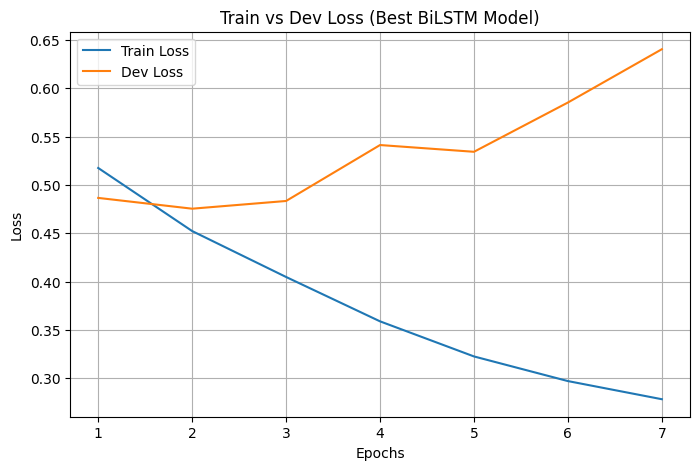

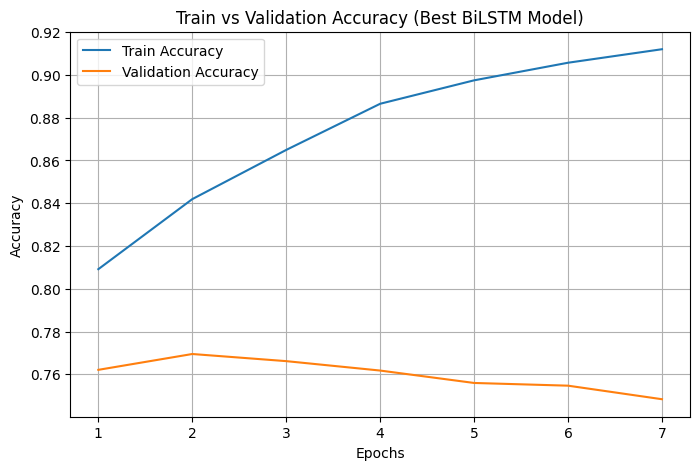

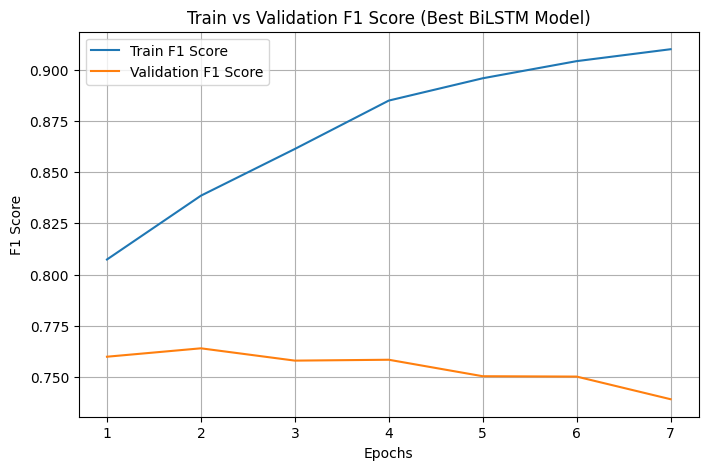

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, title_suffix=""):

    epochs = range(1, len(history['train_loss']) + 1)

    # --- Loss ---
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['dev_loss'], label='Dev Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"Train vs Dev Loss {title_suffix}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    if 'train_accuracy' in history and 'val_accuracy' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
        plt.plot(epochs, history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title(f"Train vs Validation Accuracy {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()

    # --- F1 Score ---
    if 'train_f1' in history and 'val_f1' in history:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history['train_f1'], label='Train F1 Score')
        plt.plot(epochs, history['val_f1'], label='Validation F1 Score')
        plt.xlabel("Epochs")
        plt.ylabel("F1 Score")
        plt.title(f"Train vs Validation F1 Score {title_suffix}")
        plt.legend()
        plt.grid(True)
        plt.show()


plot_training_history(history_rnn, title_suffix="(Best BiLSTM Model)")

## **Comparison with other models**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

def per_class_prf(y_true, y_pred, label_order):
    P, R, F1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_order, average=None, zero_division=0
    )
    return {lbl: (float(p), float(r), float(f1)) for lbl, p, r, f1 in zip(label_order, P, R, F1)}

def per_class_prauc(y_true, proba, label_order):
    y_true = np.asarray(y_true)
    ap = {}
    for j, lbl in enumerate(label_order):
        y_bin = (y_true == lbl).astype(int)
        y_score = proba[:, j]
        ap[lbl] = float(average_precision_score(y_bin, y_score))
    return ap

def make_results_row(name, y_true, y_pred, y_proba, label_order):
    prf = per_class_prf(y_true, y_pred, label_order)
    ap  = per_class_prauc(y_true, y_proba, label_order)

    row = {"Model": name}
    per_class_vals = []
    for lbl in label_order:
        P, R, F1 = prf[lbl]
        A = ap[lbl]
        row[f"P({lbl})"]      = P
        row[f"R({lbl})"]      = R
        row[f"F1({lbl})"]     = F1
        row[f"PR-AUC({lbl})"] = A
        per_class_vals.append((P, R, F1, A))

    macro = np.mean(per_class_vals, axis=0)
    row["Macro-P"]      = float(macro[0])
    row["Macro-R"]      = float(macro[1])
    row["Macro-F1"]     = float(macro[2])
    row["Macro-PR-AUC"] = float(macro[3])
    return row


In [ ]:
# 1) Majority baseline
baseline = baseline      # already fitted earlier, or refit

# 2) Best LR from exercise 2
best_lr = lr_tfidf       # treat this as "TF-IDF+LR"

# 3) MLP wrapper so we can call predict / predict_proba
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model.eval().to("cpu")

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            preds = torch.argmax(logits, dim=1).numpy()
        return preds

    def predict_proba(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_tensor)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

mlp_clf = MLPWrapper(best_model_mlp)


In [ ]:

class BiLSTMWrapper:
    """
    Wrapper for BiLSTM + self-attention to behave like a sklearn classifier.
    Uses the same Dataset + DataLoader pipeline as training.
    """
    def __init__(self, model, str2idx, batch_size=BATCH_SIZE, device="cpu"):
        self.model = model.to(device).eval()
        self.str2idx = str2idx
        self.batch_size = batch_size
        self.device = device

    def _make_loader(self, X, y=None):
        # if labels not provided, use dummy zeros
        labels = y if y is not None else [0] * len(X)
        dataset = TweetsSeqDataset(X, labels, self.str2idx)
        loader = DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_batch_pad
        )
        return loader

    def _predict_logits(self, X, y=None):
        loader = self._make_loader(X, y)
        all_logits = []
        self.model.eval()
        with torch.no_grad():
            for tokens, lengths, _ in loader:
                tokens = tokens.to(self.device)
                lengths = lengths.to(self.device)
                logits, _ = self.model(tokens, lengths)
                all_logits.append(logits.cpu())
        return torch.cat(all_logits, dim=0)

    def predict(self, X):
        logits = self._predict_logits(X)
        return torch.argmax(logits, dim=1).numpy()

    def predict_proba(self, X):
        logits = self._predict_logits(X)
        return torch.softmax(logits, dim=1).numpy()


rnn_clf = BiLSTMWrapper(best_model_rnn, str2idx, batch_size=BATCH_SIZE, device=device)

In [ ]:
import gc

label_order = [0, 1]  # Negative, Positive

train_rows = []
dev_rows = []
test_rows = []

# Baseline
baseline.fit(x_train, y_train)  # baseline works on raw text, ok
y_train_pred_b = baseline.predict(x_train)
y_dev_pred_b   = baseline.predict(x_dev)
y_test_pred_b  = baseline.predict(x_test)

y_train_proba_b = baseline.predict_proba(x_train)
y_dev_proba_b   = baseline.predict_proba(x_dev)
y_test_proba_b  = baseline.predict_proba(x_test)

train_rows.append(make_results_row("Baseline", y_train, y_train_pred_b, y_train_proba_b, label_order))
dev_rows.append(make_results_row("Baseline",   y_dev,   y_dev_pred_b,   y_dev_proba_b,   label_order))
test_rows.append(make_results_row("Baseline",  y_test,  y_test_pred_b,  y_test_proba_b,  label_order))

del y_train_pred_b, y_dev_pred_b, y_test_pred_b
del y_train_proba_b, y_dev_proba_b, y_test_proba_b
gc.collect()

# TF-IDF + LR (best from assg 2)
best_lr.fit(x_train, y_train)
y_train_pred_lr = best_lr.predict(x_train)
y_dev_pred_lr   = best_lr.predict(x_dev)
y_test_pred_lr  = best_lr.predict(x_test)

y_train_proba_lr = best_lr.predict_proba(x_train)
y_dev_proba_lr   = best_lr.predict_proba(x_dev)
y_test_proba_lr  = best_lr.predict_proba(x_test)

train_rows.append(make_results_row("TF-IDF+LR", y_train, y_train_pred_lr, y_train_proba_lr, label_order))
dev_rows.append(make_results_row("TF-IDF+LR",   y_dev,   y_dev_pred_lr,   y_dev_proba_lr,   label_order))
test_rows.append(make_results_row("TF-IDF+LR",  y_test,  y_test_pred_lr,  y_test_proba_lr,  label_order))

del y_train_pred_lr, y_dev_pred_lr, y_test_pred_lr
del y_train_proba_lr, y_dev_proba_lr, y_test_proba_lr
gc.collect()

# MLP (on SVD features)
y_train_pred_m = mlp_clf.predict(X_train_svd)
y_dev_pred_m   = mlp_clf.predict(X_dev_svd)
y_test_pred_m  = mlp_clf.predict(X_test_svd)

y_train_proba_m = mlp_clf.predict_proba(X_train_svd)
y_dev_proba_m   = mlp_clf.predict_proba(X_dev_svd)
y_test_proba_m  = mlp_clf.predict_proba(X_test_svd)

train_rows.append(make_results_row("MLP", y_train, y_train_pred_m, y_train_proba_m, label_order))
dev_rows.append(make_results_row("MLP",   y_dev,   y_dev_pred_m,   y_dev_proba_m,   label_order))
test_rows.append(make_results_row("MLP",  y_test,  y_test_pred_m,  y_test_proba_m,  label_order))

del X_train_svd, X_dev_svd, X_test_svd
del y_train_pred_m, y_dev_pred_m, y_test_pred_m
del y_train_proba_m, y_dev_proba_m, y_test_proba_m
del mlp_clf
del best_model_mlp
gc.collect()

# RNN

y_train_pred_rnn = rnn_clf.predict(train_clean_x)
y_dev_pred_rnn   = rnn_clf.predict(dev_clean_x)
y_test_pred_rnn  = rnn_clf.predict(test_clean_x)

y_train_proba_rnn = rnn_clf.predict_proba(train_clean_x)
y_dev_proba_rnn   = rnn_clf.predict_proba(dev_clean_x)
y_test_proba_rnn  = rnn_clf.predict_proba(test_clean_x)

train_rows.append(make_results_row("BiLSTM", train_clean_y, y_train_pred_rnn, y_train_proba_rnn, label_order))
dev_rows.append(make_results_row("BiLSTM",   dev_clean_y,   y_dev_pred_rnn,   y_dev_proba_rnn,   label_order))
test_rows.append(make_results_row("BiLSTM",  test_clean_y,  y_test_pred_rnn,  y_test_proba_rnn,  label_order))

#################################################
cols = ["Model"]
for lbl in label_order:
    cols += [f"P({lbl})", f"R({lbl})", f"F1({lbl})", f"PR-AUC({lbl})"]
cols += ["Macro-P", "Macro-R", "Macro-F1", "Macro-PR-AUC"]

train_df = pd.DataFrame(train_rows)[cols]
dev_df   = pd.DataFrame(dev_rows)[cols]
test_df  = pd.DataFrame(test_rows)[cols]

print("=== TRAIN RESULTS ===")
display(train_df)
print("\n=== DEV RESULTS ===")
display(dev_df)
print("\n=== TEST RESULTS ===")
display(test_df)


=== TRAIN RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435364,0.564636,1.000000,0.721747,0.564636,0.282318,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.793206,0.827645,0.810060,0.878431,0.862502,0.833629,0.847820,0.930190,0.827854,0.830637,0.828940,0.904310
2,MLP,0.830395,0.701661,0.760619,0.867907,0.794526,0.889499,0.839334,0.910626,0.812460,0.795580,0.799977,0.889266
3,BiLSTM,0.830777,0.799881,0.815036,0.890813,0.849938,0.874320,0.861957,0.937867,0.840357,0.837101,0.838496,0.914340



=== DEV RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435391,0.564609,1.000000,0.721725,0.564609,0.282304,0.500000,0.360863,0.500000
1,TF-IDF+LR,0.722174,0.757121,0.739234,0.805588,0.805447,0.775390,0.790132,0.876435,0.763810,0.766255,0.764683,0.841011
2,MLP,0.709568,0.608729,0.655292,0.746550,0.728076,0.807865,0.765898,0.826373,0.718822,0.708297,0.710595,0.786461
3,BiLSTM,0.748343,0.712308,0.729881,0.810292,0.785796,0.815017,0.800140,0.881620,0.767070,0.763662,0.765010,0.845956



=== TEST RESULTS ===


,Model,P(0),R(0),F1(0),PR-AUC(0),P(1),R(1),F1(1),PR-AUC(1),Macro-P,Macro-R,Macro-F1,Macro-PR-AUC
0,Baseline,0.000000,0.000000,0.000000,0.435362,0.564638,1.000000,0.721749,0.564638,0.282319,0.500000,0.360874,0.500000
1,TF-IDF+LR,0.726814,0.750077,0.738262,0.810192,0.802421,0.782619,0.792396,0.875979,0.764618,0.766348,0.765329,0.843085
2,MLP,0.713409,0.605360,0.654958,0.753251,0.727532,0.812493,0.767669,0.825070,0.720471,0.708926,0.711314,0.789160
3,BiLSTM,0.750205,0.704913,0.726854,0.813666,0.782766,0.819174,0.800557,0.879238,0.766486,0.762044,0.763705,0.846452
